In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('../data/ethiopia.csv')
df['Country'] = 'Ethiopia'
print(df.shape)
df.head()

(4108, 13)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [5]:
df = df.replace(-999, np.nan)
print("Missing values after replacement:")
print(df.isna().sum())

Missing values after replacement:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [6]:
# DOY = day of year (001 to 365/366)
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Year,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,2015,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,2015,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,2015,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,2015,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,2015,1


In [8]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

Number of duplicate rows: 0
Shape after dropping duplicates: (4108, 16)


In [9]:
# Basic statistics of numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Year,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,2020.131451,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,2015.000000,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,2017.000000,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,2020.000000,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,2023.000000,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,2026.000000,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.248907,3.477046


In [10]:
# Percentage of missing values per column
missing_pct = df.isna().sum() / len(df) * 100
print(missing_pct[missing_pct > 0])

Series([], dtype: float64)


In [11]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outlier_counts = {}
for col in cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    outliers = (z > 3).sum()
    outlier_counts[col] = outliers
    print(f"{col}: {outliers} outliers")

# We'll cap outliers to 3 standard deviations (you can also drop them – document your choice)
for col in cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col] = df[col].clip(mean - 3*std, mean + 3*std)

T2M: 3 outliers
T2M_MAX: 0 outliers
T2M_MIN: 18 outliers
PRECTOTCORR: 95 outliers
RH2M: 13 outliers
WS2M: 3 outliers
WS2M_MAX: 5 outliers


In [13]:
# Forward fill for weather variables (use the last valid observation)
df[cols] = df[cols].ffill()

# Drop rows that still have more than 30% missing values
df = df.dropna(thresh=int(0.7 * len(df.columns)))
print(f"Final shape: {df.shape}")

Final shape: (4108, 16)


In [14]:
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Saved cleaned data to ../data/ethiopia_clean.csv")

Saved cleaned data to ../data/ethiopia_clean.csv


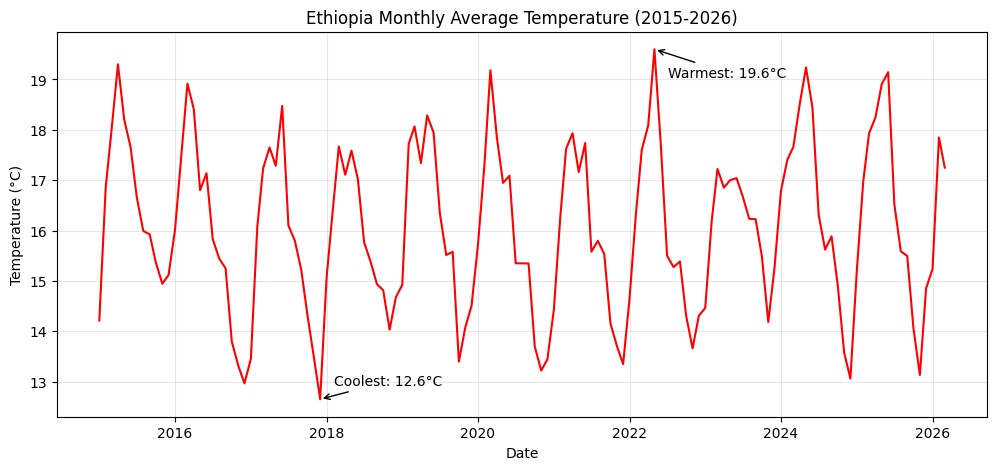

In [15]:
monthly_temp = df.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp['Year'].astype(str) + '-' + monthly_temp['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], linewidth=1.5, color='red')

# Find warmest and coolest months
max_row = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
min_row = monthly_temp.loc[monthly_temp['T2M'].idxmin()]
plt.annotate(f"Warmest: {max_row['T2M']:.1f}°C", xy=(max_row['Date'], max_row['T2M']),
             xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f"Coolest: {min_row['T2M']:.1f}°C", xy=(min_row['Date'], min_row['T2M']),
             xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.title('Ethiopia Monthly Average Temperature (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.show()

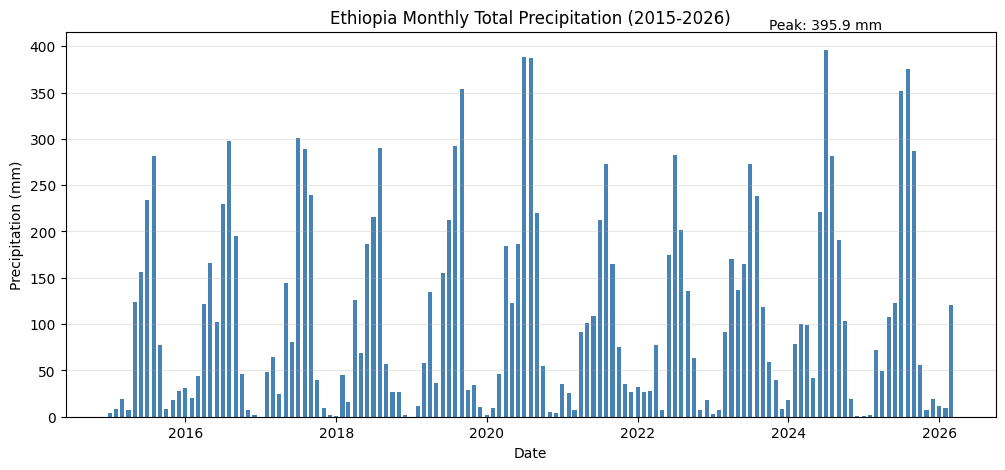

In [16]:
monthly_precip = df.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().reset_index()
monthly_precip['Date'] = pd.to_datetime(monthly_precip['Year'].astype(str) + '-' + monthly_precip['Month'].astype(str))

plt.figure(figsize=(12,5))
plt.bar(monthly_precip['Date'], monthly_precip['PRECTOTCORR'], width=20, color='steelblue')
peak = monthly_precip.loc[monthly_precip['PRECTOTCORR'].idxmax()]
plt.annotate(f"Peak: {peak['PRECTOTCORR']:.1f} mm", xy=(peak['Date'], peak['PRECTOTCORR']),
             xytext=(0, 15), textcoords='offset points', ha='center')
plt.title('Ethiopia Monthly Total Precipitation (2015-2026)')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm)')
plt.grid(alpha=0.3, axis='y')
plt.show()

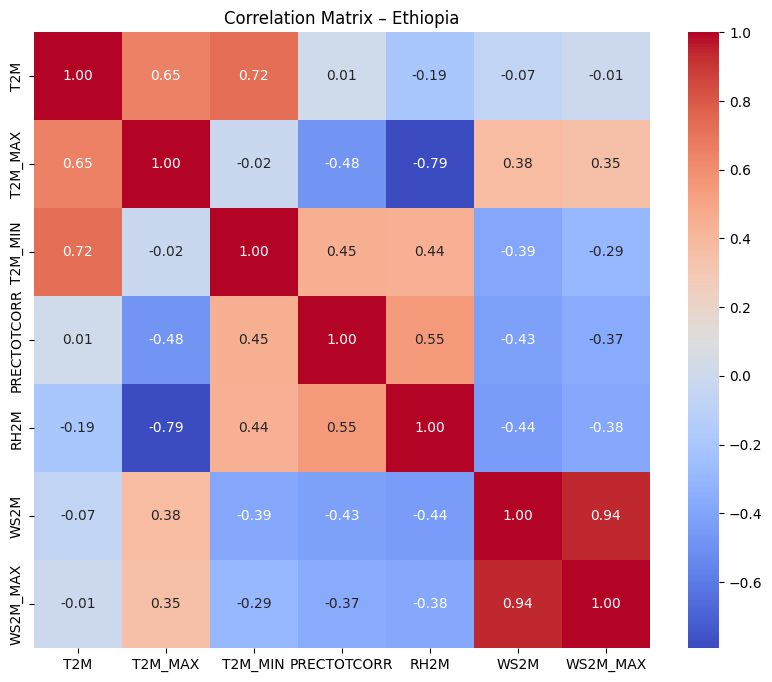

In [17]:
plt.figure(figsize=(10,8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix – Ethiopia')
plt.show()

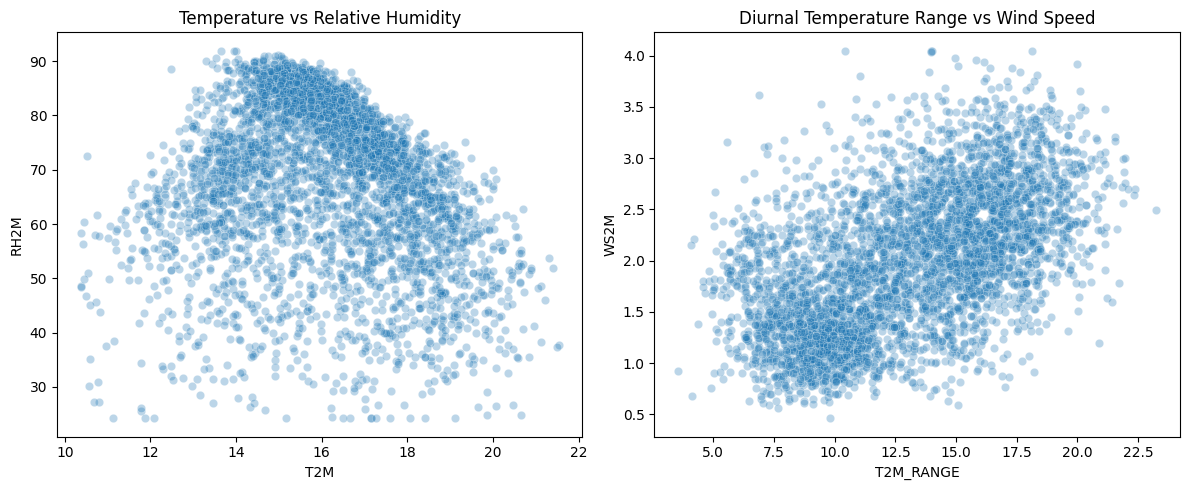

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=axes[1])
axes[1].set_title('Diurnal Temperature Range vs Wind Speed')
plt.tight_layout()
plt.show()

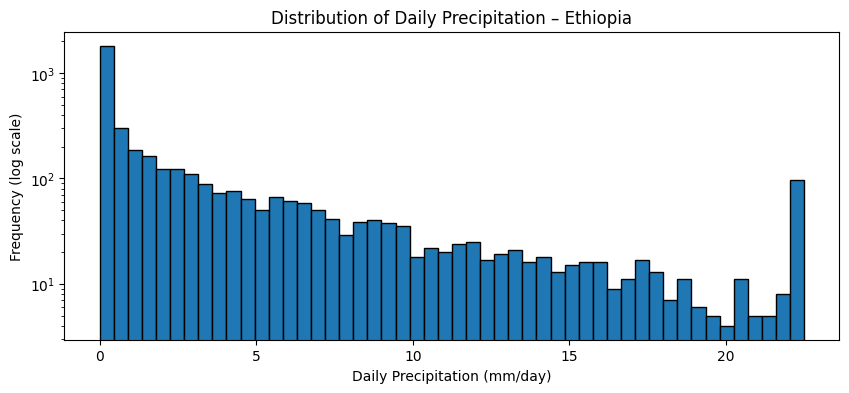

In [19]:
plt.figure(figsize=(10,4))
plt.hist(df['PRECTOTCORR'], bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Frequency (log scale)')
plt.title('Distribution of Daily Precipitation – Ethiopia')
plt.show()

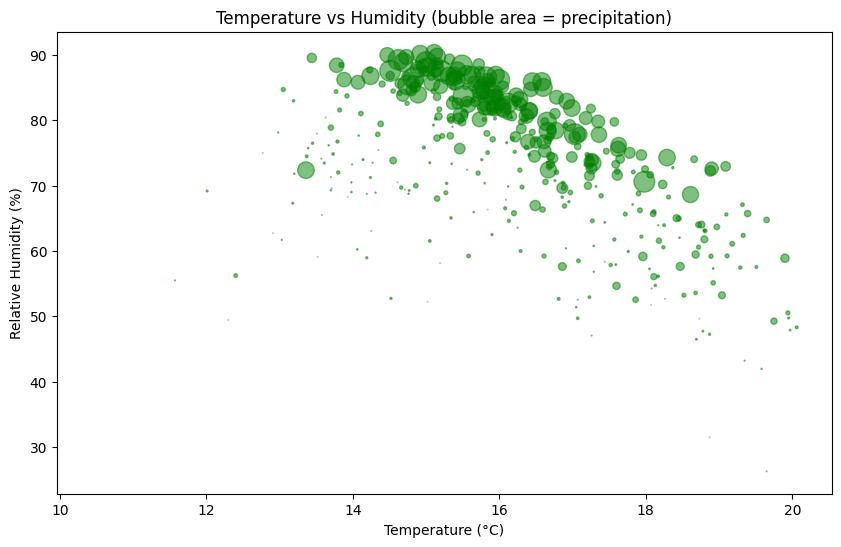

In [20]:
sample = df.sample(min(500, len(df)))  # avoid overcrowding
plt.figure(figsize=(10,6))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5, c='green')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temperature vs Humidity (bubble area = precipitation)')
plt.show()